# Klasifikasi Berita

## Crawling Web Berita

*Crawling Web Berita* merupakan Proses untuk mengotomatisasi untuk menjelajahi sebuah situs web untuk mengumpulkan informasi dari halaman-halaman web. proses ini oleh komputer dikenal dengan istilah Web Crawler. Web crawler akan memulai dengan mengunjungi sebuah halaman web, mengekstrak semua tautan di halaman tersebut, kemudian mengikuti tautan tersebut untuk mengunjungi halaman-halaman lain dan mengumpulkan data yang diperlukan.

### Implementasi Crawling

pada proses ini, saya mengambil data dari website SINDONEWS pada tanggal 04-10-2024. Data yang akan saya kumpulkan mencangkup 2 kategori yaitu Internasional dan Nasional. <br>
link : https://www.sindonews.com/

#### Import Library

In [1]:
# pip install scrapy

In [2]:
# Library yang saya gunakan
import scrapy
from scrapy.crawler import CrawlerProcess
import pandas as pd
import matplotlib.pyplot as plt

* *Scrapy* sebagai framework untuk scraping web scraping
* *from scrapy.crawler import CrawlerProcess* untuk menjalankan crawler scrapy
* *Pandas* untuk memanipulasi data
* *Matplotlib* untuk memvisualisasikan Data

#### Code Program

In [3]:
import scrapy
from scrapy.crawler import CrawlerProcess

class CrawlingWeb(scrapy.Spider):
    name = "SindonewsLinks"

    custom_settings = {
        'FEEDS': {
            'Terbaru.csv': {
                'format': 'csv',
                'overwrite': True,
            },
        },
        'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    }

    def start_requests(self):
        # Base URLs dan kategori yang sesuai
        urls_and_categories = [
            ("https://international.sindonews.com/more/9", "internasional"),
            ("https://nasional.sindonews.com/more/5", "nasional")
        ]

        # Loop untuk men-generate URL dari halaman-halaman yang diinginkan
        for base_url, kategori in urls_and_categories:
            for i in range(0, 100, 20):  # Iterasi setiap 20 (pagination)
                url = f"{base_url}{i}"
                print(f"Mengambil URL: {url}, Kategori: {kategori}")  # Print URL yang sedang diakses
                # Memasukkan kategori sebagai meta data
                yield scrapy.Request(url=url, callback=self.parse, meta={'kategori': kategori})

    def parse(self, response):
        # Mendapatkan kategori dari meta data
        kategori = response.meta['kategori']
        print(f"Status Response: {response.status}, Kategori: {kategori}")

        # Mengambil link berita dari indeks dengan CSS selector yang lebih umum
        for data in response.css('div.terkini div.grid-kanal-small'):
          link_berita = data.css('a::attr(href)').get()
          if link_berita:
            print(f"Mengambil Link Berita: {link_berita}")
            # Memasukkan kategori ke dalam meta untuk diteruskan ke `parse_detail`
            yield response.follow(link_berita, callback=self.parse_detail, meta={'kategori': kategori})
          else:
            print("Link tidak terambil")


    def parse_detail(self, response):
        # Ekstrak data dari halaman detail berita
        judul_berita = response.css('div.detail-title > h1::text').get()
        isi_berita = response.css('div.detail-desc').get()
        tanggal_berita = response.css('div.detail-date-artikel::text').get()
        kategori = response.meta['kategori']

         # untuk mendapatkan semua paragraf
        if isi_berita:
            isi_berita = ''.join(response.css('div.detail-desc *::text').getall()).strip()

        # Debugging: print data yang diambil
        print(f"Judul: {judul_berita}, Tanggal: {tanggal_berita}, Kategori: {kategori}")

        # Simpan data yang diekstrak ke dalam file CSV
        yield {
            'Judul': judul_berita,
            'Isi Berita': isi_berita,
            'Tanggal Berita': tanggal_berita,
            'Kategori': kategori,
        }

# Menjalankan Spider
process = CrawlerProcess()
process.crawl(CrawlingWeb)
process.start()

2024-12-10 21:52:56 [scrapy.utils.log] INFO: Scrapy 2.8.0 started (bot: scrapybot)


2024-12-10 21:52:56 [scrapy.utils.log] INFO: Versions: lxml 4.9.3.0, libxml2 2.10.4, cssselect 1.2.0, parsel 1.8.1, w3lib 2.1.2, Twisted 23.10.0, Python 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)], pyOpenSSL 24.0.0 (OpenSSL 3.3.1 4 Jun 2024), cryptography 42.0.2, Platform Windows-10-10.0.22631-SP0


2024-12-10 21:52:56 [scrapy.crawler] INFO: Overridden settings:
{'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
               '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}


2024-12-10 21:52:56 [py.warnings] WARNING: C:\Users\Lenovo\anaconda3\Lib\site-packages\scrapy\utils\request.py:232: ScrapyDeprecationWarning: '2.6' is a deprecated value for the 'REQUEST_FINGERPRINTER_IMPLEMENTATION' setting.

It is also the default value. In other words, it is normal to get this warning if you have not defined a value for the 'REQUEST_FINGERPRINTER_IMPLEMENTATION' setting. This is so for backward compatibility reasons, but it will change in a future version of Scrapy.

See the documentation of the 'REQUEST_FINGERPRINTER_IMPLEMENTATION' setting for information on how to handle this deprecation.
  return cls(crawler)



2024-12-10 21:52:56 [scrapy.utils.log] DEBUG: Using reactor: twisted.internet.selectreactor.SelectReactor


...

2024-12-10 21:52:57 [scrapy.middleware] INFO: Enabled item pipelines:
[]


2024-12-10 21:52:57 [scrapy.core.engine] INFO: Spider opened


2024-12-10 21:52:57 [scrapy.extensions.logstats] INFO: Crawled 0 pages (at 0 pages/min), scraped 0 items (at 0 items/min)


2024-12-10 21:52:57 [scrapy.extensions.telnet] INFO: Telnet console listening on 127.0.0.1:6023


AttributeError: 'SelectReactor' object has no attribute '_handleSignals'

Code diatas, berguna untuk mengambil setiap data berita dari Judul, Isi Berita, Tanggal Berita dan Kategori Berita.

### Menampilkan Data

In [5]:
df = pd.read_csv('Sindonews.csv')
df

,Judul,Isi Berita,Tanggal Berita,Kategori
0,Kejagung Beberkan Peran Tom Lembong di Kasus I...,JAKARTA - Kejaksaan Agung (Kejagung) menetapka...,"Selasa, 29 Oktober 2024 - 22:02 WIB",nasional
1,"Prabowo Larang Menteri Pakai Mobil Impor, Mobi...",JAKARTA - Presiden Prabowo Subianto meminta ...,"Senin, 28 Oktober 2024 - 17:54 WIB",nasional
2,"Instruksikan Menteri Gunakan Maung, Logis 08: ...",JAKARTA - Presiden terpilih Prabowo Subianto k...,"Rabu, 30 Oktober 2024 - 19:45 WIB",nasional
3,"7 Fakta Ipda Rudy Soik, Perwira Polisi yang Di...","JAKARTA - Ipda Rudy Soik , Anggota Polda Nusa...","Senin, 28 Oktober 2024 - 17:52 WIB",nasional
4,Bendum Perindo Angkie Yudistia Terima Pengharg...,JAKARTA - Bendahara Umum (Bendum) Partai Perin...,"Selasa, 29 Oktober 2024 - 21:53 WIB",nasional
...,...,...,...,...
227,Butuh 1 Tahun Tetapkan Tom Lembong Jadi Tersan...,JAKARTA - Kejaksaan Agung (Kejagung) memberika...,"Rabu, 30 Oktober 2024 - 18:27 WIB",nasional
228,Menteri ATR/BPN Nusron Wahid Ingin Mafia Tanah...,JAKARTA - Menteri Agraria dan Tata Ruang/Kepal...,"Rabu, 30 Oktober 2024 - 12:35 WIB",nasional
229,PGN Siap Ambil Peran dalam Gotong Royong Bangu...,JAKARTA - PT PGN Tbk selaku Subholding Gas Per...,"Rabu, 30 Oktober 2024 - 12:35 WIB",nasional
230,Kapolri Siapkan Program 100 Hari Sukseskan Ast...,JAKARTA - Kapolri Jenderal Polisi Listyo Sig...,"Selasa, 29 Oktober 2024 - 13:13 WIB",nasional


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Judul           232 non-null    object
 1   Isi Berita      232 non-null    object
 2   Tanggal Berita  232 non-null    object
 3   Kategori        232 non-null    object
dtypes: object(4)
memory usage: 7.4+ KB


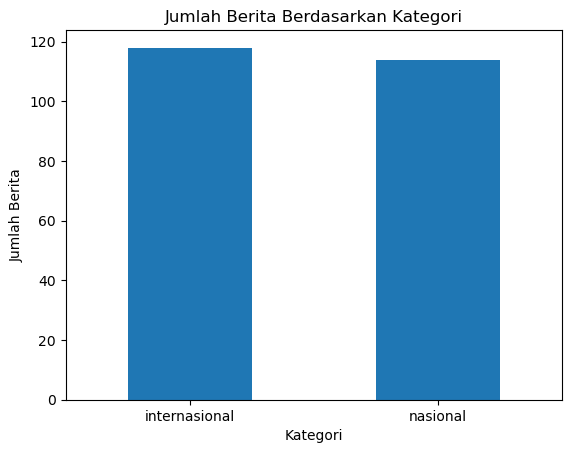

In [9]:
Visual = df.Kategori.value_counts()
Visual.plot(kind='bar')
plt.xticks(rotation=0)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Berita')
plt.title('Jumlah Berita Berdasarkan Kategori')
plt.show()

Data Hasil Crawling Dari portal berita **SindoNews** berjumlah 200 dengan 2 kategori yaitu Nasional dan Internasional.